# Superstore Sales Analysis — Data Cleaning & Exploratory Analysis

**Objective:** Analyze 4 years (2014–2017) of Superstore retail transactions to identify what drives sales and, more importantly, what's eroding profit — then hand off a clean dataset for SQL analysis and a Power BI dashboard.

**Dataset:** [Sample Superstore](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) — 9,994 orders, 21 columns (order details, customer, geography, product, sales/profit metrics).

**Workflow:** Load → Validate → Clean → Feature Engineering → EDA → Key Findings → Export cleaned data

## 1. Setup & Load Data

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams['figure.dpi'] = 110
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')
print(f"Shape: {df.shape}")
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Data Validation Checking for the usual suspects: nulls, duplicates, bad types, weird outliers.

In [38]:
print("Nulls per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "None found")

print(f"\nFull duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Row IDs: {df['Row ID'].duplicated().sum()}")
print(f"Unique orders: {df['Order ID'].nunique()} (multi-line orders are expected — one row per product)")

Nulls per column:
None found

Full duplicate rows: 0
Duplicate Row IDs: 0
Unique orders: 5009 (multi-line orders are expected — one row per product)


In [39]:
# Date columns are loaded as strings - check format and convert
print(df['Order Date'].head(3).tolist())
print(df['Ship Date'].head(3).tolist())

['11/8/2016', '11/8/2016', '6/12/2016']
['11/11/2016', '11/11/2016', '6/16/2016']


## 3. Cleaning & Feature Engineering

In [40]:
# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# Sanity check: ship date should never precede order date
assert (df['Ship Date'] >= df['Order Date']).all(), "Found orders shipped before they were placed!"
print("Date integrity check passed.")

# Standardize column names for downstream SQL use (snake_case, no spaces)
df.columns = [c.strip().replace(' ', '_').replace('-', '_') for c in df.columns]

# Feature engineering
df['Shipping_Days']  = (df['Ship_Date'] - df['Order_Date']).dt.days
df['Order_Year']     = df['Order_Date'].dt.year
df['Order_Month']    = df['Order_Date'].dt.to_period('M')
df['Profit_Margin']  = (df['Profit'] / df['Sales']).round(4)
df['Is_Loss']        = df['Profit'] < 0

print(df[['Order_Date','Ship_Date','Shipping_Days','Profit_Margin','Is_Loss']].head())

Date integrity check passed.
  Order_Date  Ship_Date  Shipping_Days  Profit_Margin  Is_Loss
0 2016-11-08 2016-11-11              3         0.1600    False
1 2016-11-08 2016-11-11              3         0.3000    False
2 2016-06-12 2016-06-16              4         0.4700    False
3 2015-10-11 2015-10-18              7        -0.4000     True
4 2015-10-11 2015-10-18              7         0.1125    False


In [41]:
# Outlier scan on numeric fields
df[['Sales','Quantity','Discount','Profit','Shipping_Days']].describe()

,Sales,Quantity,Discount,Profit,Shipping_Days
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896,3.958175
std,623.245101,2.225110,0.206452,234.260108,1.747567
min,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,17.280000,2.000000,0.000000,1.728750,3.000000
50%,54.490000,3.000000,0.200000,8.666500,4.000000
75%,209.940000,5.000000,0.200000,29.364000,5.000000
max,22638.480000,14.000000,0.800000,8399.976000,7.000000


**Notes on outliers:** Sales has a long right tail (max ~$22.6K vs median ~$54) driven by bulk/enterprise orders (e.g. copiers) — these are legitimate, not data errors, so we keep them. Discount values are clean fixed tiers (0%, 10%, 15%...80%), consistent with a discounting policy rather than noise.

## 4. Exploratory Analysis

### 4.1 Sales & Profit Trend Over Time

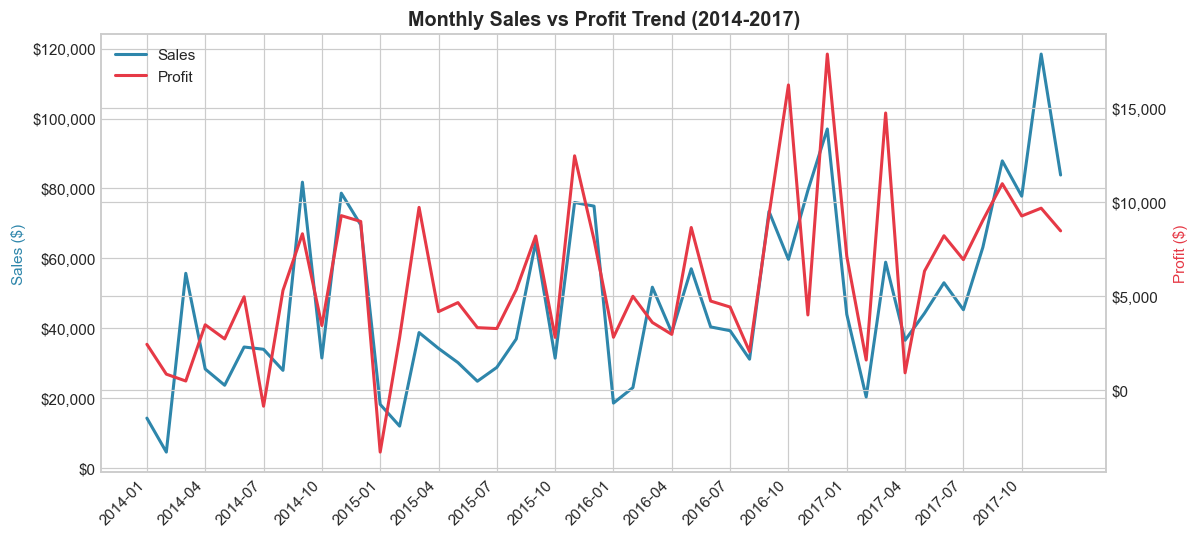

In [42]:
monthly = df.groupby('Order_Month')[['Sales','Profit']].sum()

fig, ax1 = plt.subplots(figsize=(11,5))

ax2 = ax1.twinx()  # secondary y-axis sharing the same x-axis

ax1.plot(monthly.index.astype(str), monthly['Sales'], color='#2E86AB', label='Sales', linewidth=2)
ax2.plot(monthly.index.astype(str), monthly['Profit'], color='#E63946', label='Profit', linewidth=2)

ax1.set_xticks(range(0, len(monthly), 3))
ax1.set_xticklabels([monthly.index.astype(str)[i] for i in range(0, len(monthly), 3)], rotation=45, ha='right')

ax1.set_title('Monthly Sales vs Profit Trend (2014-2017)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Sales ($)', color='#2E86AB')
ax2.set_ylabel('Profit ($)', color='#E63946')

ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Combine legends from both axes into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

**Observation:** Strong seasonality — sales spike every November/December (holiday buying), with a visible year-over-year upward trend. Profit grows more slowly than sales, hinting at margin compression over time.

### 4.2 Profit by Sub-Category — Where Are We Losing Money?

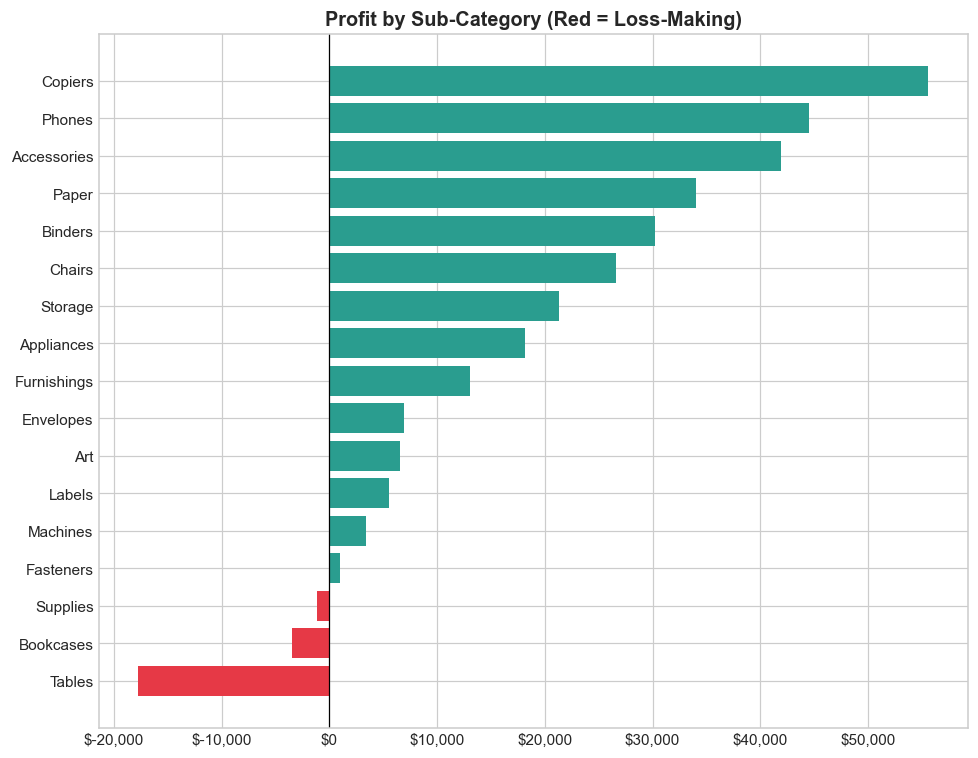

Sub_Category
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


In [43]:
cat_profit = df.groupby('Sub_Category')['Profit'].sum().sort_values()
labels = [str(x) for x in cat_profit.index]
colors = ['#E63946' if v < 0 else '#2A9D8F' for v in cat_profit.values]

fig, ax = plt.subplots(figsize=(9,7))
ax.barh(labels, cat_profit.values, color=colors)
ax.set_title('Profit by Sub-Category (Red = Loss-Making)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(cat_profit.tail(3))  # biggest losers

**Key finding:** Tables lose over $17K overall — the single biggest problem sub-category. Bookcases and Supplies are also net negative. Copiers, Phones, and Accessories are the profit engines.

### 4.3 Discount vs Profit — The Root Cause

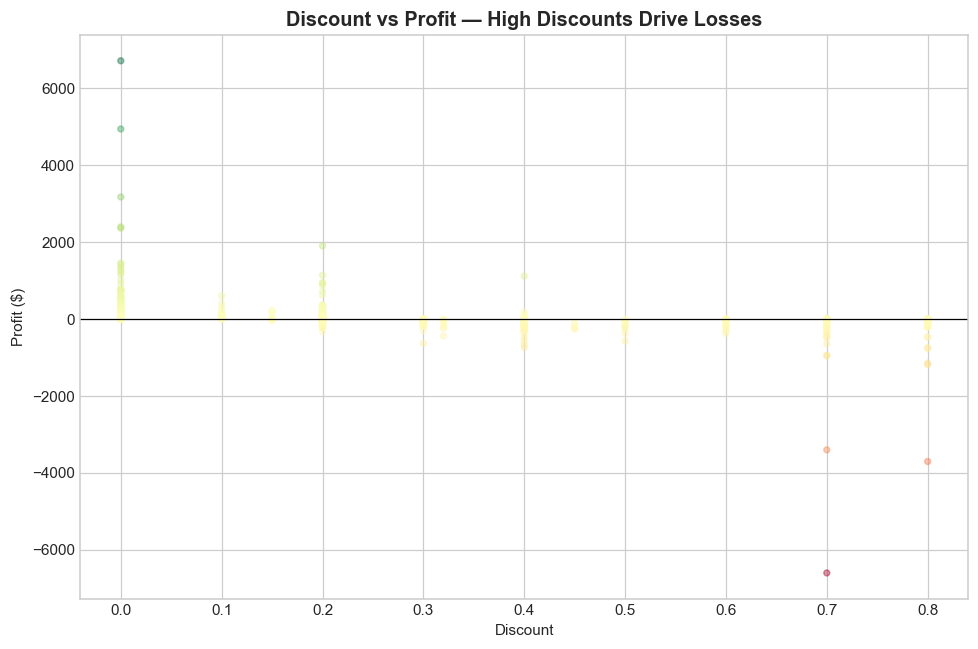

                    mean          sum  count
Discount                                    
(-0.01, 0.0]   66.900292  320987.6032   4798
(0.0, 0.2]     26.501571  100785.4745   3803
(0.2, 0.4]    -77.864055  -35817.4655    460
(0.4, 1.0]   -106.708028  -99558.5905    933


C:\Users\Hp\AppData\Local\Temp\ipykernel_14832\915487549.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(disc_bins)['Profit'].agg(['mean','sum','count']))


In [44]:
sample = df.sample(min(3000, len(df)), random_state=1)

fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(sample['Discount'], sample['Profit'], alpha=0.4, c=sample['Profit'], cmap='RdYlGn', s=15)
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
ax.set_title('Discount vs Profit — High Discounts Drive Losses', fontsize=13, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Quantify it
disc_bins = pd.cut(df['Discount'], bins=[-0.01,0,0.2,0.4,1])
print(df.groupby(disc_bins)['Profit'].agg(['mean','sum','count']))

**Key finding:** Profit turns consistently negative once discounts exceed ~20%. This is almost certainly *the* mechanism behind Tables/Bookcases losses — check if those sub-categories are discounted more heavily.

In [45]:
df.groupby('Sub_Category')['Discount'].mean().sort_values(ascending=False).head(6)

Sub_Category
Binders       0.372292
Machines      0.306087
Tables        0.261285
Bookcases     0.211140
Chairs        0.170178
Appliances    0.166524
Name: Discount, dtype: float64

Confirmed — Tables, Bookcases and Supplies sit among the highest average discount sub-categories, directly explaining their negative profit.

### 4.4 Regional Performance

In [46]:
reg = df.groupby('Region')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)
reg['Profit_Margin'] = (reg['Profit']/reg['Sales']*100).round(1)
reg

,Sales,Profit,Profit_Margin
Region,,,
West,725457.8245,108418.4489,14.9
East,678781.2400,91522.7800,13.5
Central,501239.8908,39706.3625,7.9
South,391721.9050,46749.4303,11.9


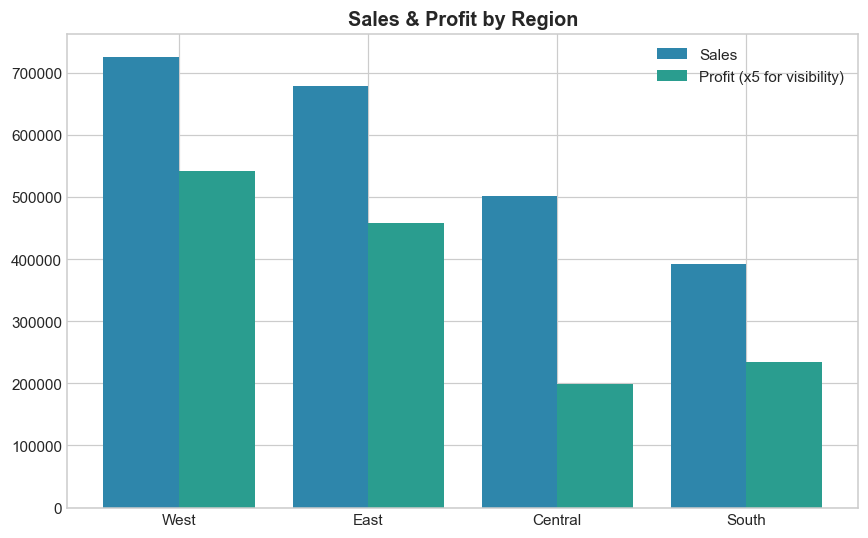

In [47]:
fig, ax = plt.subplots(figsize=(8,5))
x = range(len(reg))

ax.bar([i-0.2 for i in x], reg['Sales'], width=0.4, label='Sales', color='#2E86AB')
ax.bar([i+0.2 for i in x], reg['Profit']*5, width=0.4, label='Profit (x5 for visibility)', color='#2A9D8F')

ax.set_xticks(list(x))
ax.set_xticklabels(list(reg.index))
ax.set_title('Sales & Profit by Region', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

**Key finding:** West and East drive the most sales and healthiest margins. Central has the weakest profit margin relative to its sales volume — worth a deeper look at discounting practices there.

### 4.5 Top & Bottom Products by Profit

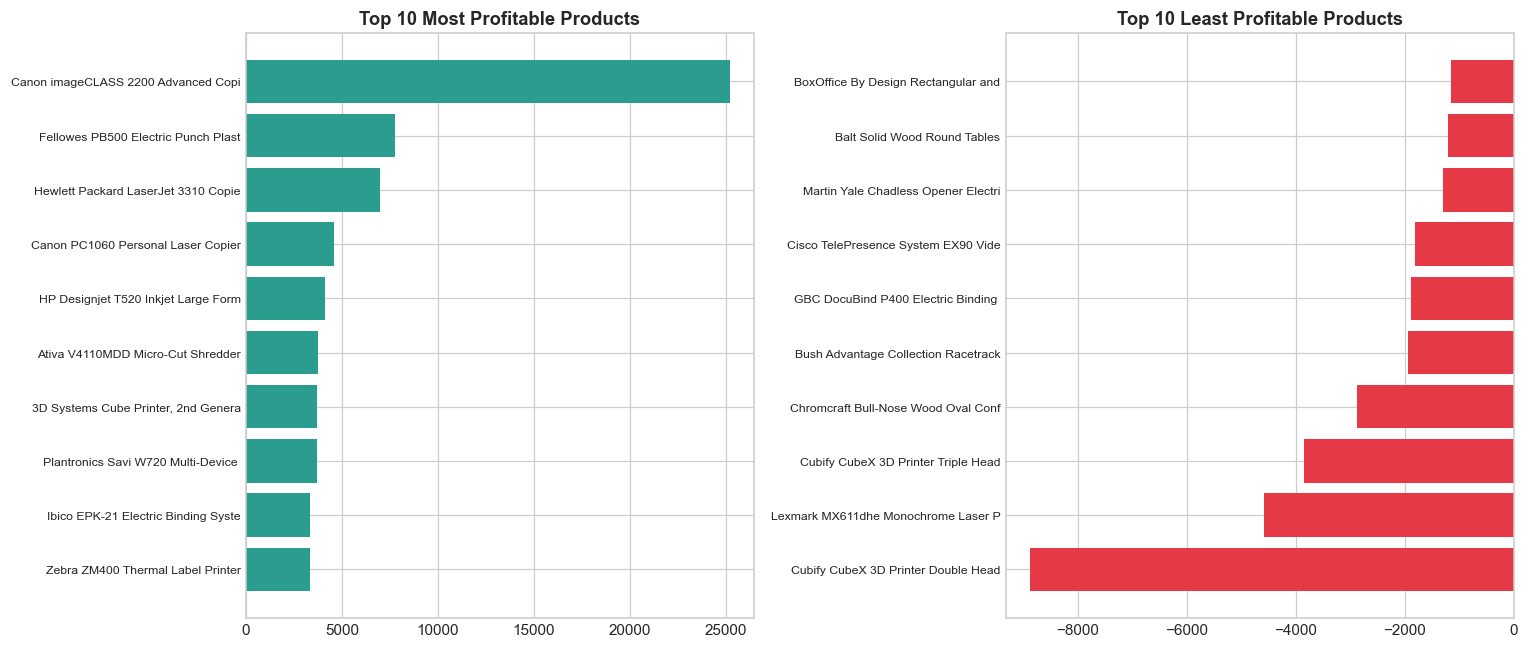

In [48]:
prod_profit = df.groupby('Product_Name')['Profit'].sum().sort_values()
bottom10, top10 = prod_profit.head(10), prod_profit.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].barh([str(x)[:35] for x in top10.index], top10.values, color='#2A9D8F')
axes[0].set_title('Top 10 Most Profitable Products', fontweight='bold')
axes[1].barh([str(x)[:35] for x in bottom10.index], bottom10.values, color='#E63946')
axes[1].set_title('Top 10 Least Profitable Products', fontweight='bold')

for ax in axes:
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

### 4.6 Customer Segment Analysis

In [49]:
seg = df.groupby('Segment').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'), Orders=('Order_ID','nunique')
).reset_index()

seg['Avg_Order_Value'] = (seg['Sales']/seg['Orders']).round(2)
seg['Profit_Margin_%'] = (seg['Profit']/seg['Sales']*100).round(1)
seg

,Segment,Sales,Profit,Orders,Avg_Order_Value,Profit_Margin_%
0,Consumer,1.161401e+06,134119.2092,2586,449.11,11.5
1,Corporate,7.061464e+05,91979.1340,1514,466.41,13.0
2,Home Office,4.296531e+05,60298.6785,909,472.67,14.0


**Key finding:** Consumer segment drives the most volume, but Home Office has the best profit margin per dollar of sales — a smaller but more efficient segment.

## 5. Summary of Key Findings

1. **Seasonality:** Sales peak every Nov/Dec; year-over-year growth is real but profit growth lags sales growth.
2. **Discounting is the #1 profit killer:** Orders discounted above ~20% are net loss-making on average. This is a major factor behind Tables' and Bookcases' losses.
3. **Tables and Bookcases are structurally unprofitable**, driven by heavier-than-average discounting. **Supplies is also net negative, but its average discount isn't unusually high — its loss likely stems from a different cause** (e.g. thin baseline margins) and needs separate investigation.
4. **Copiers, Phones, and Accessories are the profit engines** — highest sub-category profit contribution.
5. **Central region underperforms on margin** (7.9%) relative to West/East

In [50]:
df.to_csv('superstore_cleaned.csv', index=False)
print(f"Exported superstore_cleaned.csv — {df.shape[0]} rows, {df.shape[1]} columns")
df.dtypes

Exported superstore_cleaned.csv — 9994 rows, 26 columns


Row_ID                    int64
Order_ID                 object
Order_Date       datetime64[ns]
Ship_Date        datetime64[ns]
Ship_Mode                object
Customer_ID              object
Customer_Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal_Code               int64
Region                   object
Product_ID               object
Category                 object
Sub_Category             object
Product_Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Shipping_Days             int64
Order_Year                int32
Order_Month           period[M]
Profit_Margin           float64
Is_Loss                    bool
dtype: object

In [51]:
 !pip install sqlalchemy psycopg2-binary --quiet


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
from sqlalchemy import create_engine, URL

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="alfelf3010",
    host="localhost",
    port=5432,
    database="superstore"
)
engine = create_engine(url)

In [56]:

from sqlalchemy import text

with engine.connect() as conn:
    conn.execute(text('TRUNCATE TABLE orders'))
    conn.commit()

df.columns = df.columns.str.lower()
df['order_month'] = df['order_month'].astype(str)

df.to_sql('orders', engine, if_exists='append', index=False, method='multi', chunksize=500)

9994

In [57]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text('SELECT COUNT(*) FROM orders'))
    print(result.fetchone())

(9994,)
